<a href="https://www.kaggle.com/code/strangertv/sales-analyse?scriptVersionId=343460465" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
mkdir -p /home/claude/sales_project && cd /home/claude/sales_project

In [3]:


import pandas as pd
import numpy as np
np.random.seed(42)

n = 1000
products = ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Monitor', 'Keyboard', 'Mouse', None]
regions = ['North', 'South', 'East', 'West', 'north']  # 'north' متعمد كخطأ حالة أحرف
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')

data = {
    'order_id': range(1, n+1),
    'date': np.random.choice(dates, n),
    'product': np.random.choice(products, n, p=[0.2,0.2,0.15,0.15,0.1,0.08,0.07,0.05]),
    'region': np.random.choice(regions, n),
    'quantity': np.random.randint(1, 10, n),
    'unit_price': np.random.choice([1200, 800, 350, 150, 300, 45, 25], n),
    'customer_id': np.random.randint(1000, 1200, n),
}
df = pd.DataFrame(data)
df['total_sales'] = df['quantity'] * df['unit_price']

# إدخال قيم مفقودة متعمدة
missing_idx = np.random.choice(df.index, 40, replace=False)
df.loc[missing_idx, 'unit_price'] = np.nan

# إدخال صفوف مكررة متعمدة
dupes = df.sample(15)
df = pd.concat([df, dupes], ignore_index=True)

df.to_csv('/home/claude/sales_project/sales_data.csv', index=False)
print(df.shape)
print(df.head())


(1015, 8)
   order_id       date     product region  quantity  unit_price  customer_id  \
0         1 2024-04-12       Mouse  north         3       800.0         1017   
1         2 2024-12-14       Phone   West         4        25.0         1186   
2         3 2024-09-27  Headphones   West         6       300.0         1089   
3         4 2024-04-16       Phone   West         7        25.0         1143   
4         5 2024-03-12      Tablet  north         4        25.0         1005   

   total_sales  
0         2400  
1          100  
2         1800  
3          175  
4          100  


In [4]:
df.shape

(1015, 8)

In [5]:
df.head

<bound method NDFrame.head of       order_id       date     product region  quantity  unit_price  \
0            1 2024-04-12       Mouse  north         3       800.0   
1            2 2024-12-14       Phone   West         4        25.0   
2            3 2024-09-27  Headphones   West         6       300.0   
3            4 2024-04-16       Phone   West         7        25.0   
4            5 2024-03-12      Tablet  north         4        25.0   
...        ...        ...         ...    ...       ...         ...   
1010       585 2024-05-23     Monitor   East         5       350.0   
1011       499 2024-01-16  Headphones  North         4      1200.0   
1012       363 2024-04-23       Phone   West         5      1200.0   
1013       768 2024-02-08       Phone   East         6      1200.0   
1014       787 2024-03-06  Headphones  North         6         NaN   

      customer_id  total_sales  
0            1017         2400  
1            1186          100  
2            1089         1800

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     1015 non-null   int64         
 1   date         1015 non-null   datetime64[ns]
 2   product      964 non-null    object        
 3   region       1015 non-null   object        
 4   quantity     1015 non-null   int64         
 5   unit_price   974 non-null    float64       
 6   customer_id  1015 non-null   int64         
 7   total_sales  1015 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 63.6+ KB


In [7]:
df.describe()

,order_id,date,quantity,unit_price,customer_id,total_sales
count,1015.000000,1015,1015.000000,974.000000,1015.000000,1015.000000
mean,500.915271,2024-06-30 20:21:31.034482688,4.976355,395.877823,1101.326108,1927.990148
min,1.000000,2024-01-01 00:00:00,1.000000,25.000000,1000.000000,25.000000
25%,250.500000,2024-04-07 00:00:00,3.000000,45.000000,1049.500000,225.000000
50%,501.000000,2024-07-01 00:00:00,5.000000,300.000000,1102.000000,900.000000
75%,751.500000,2024-09-27 00:00:00,7.000000,800.000000,1152.000000,2400.000000
max,1000.000000,2024-12-31 00:00:00,9.000000,1200.000000,1199.000000,10800.000000
std,288.449478,NaN,2.614901,403.480203,57.955613,2473.376044


In [8]:
df.isnull().sum()

order_id        0
date            0
product        51
region          0
quantity        0
unit_price     41
customer_id     0
total_sales     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(15)

In [10]:
df.head()

,order_id,date,product,region,quantity,unit_price,customer_id,total_sales
0,1,2024-04-12,Mouse,north,3,800.0,1017,2400
1,2,2024-12-14,Phone,West,4,25.0,1186,100
2,3,2024-09-27,Headphones,West,6,300.0,1089,1800
3,4,2024-04-16,Phone,West,7,25.0,1143,175
4,5,2024-03-12,Tablet,north,4,25.0,1005,100


In [11]:
df["region"].unique()

array(['north', 'West', 'South', 'East', 'North'], dtype=object)

In [12]:
df["region"].value_counts()

region
West     226
north    214
East     202
North    198
South    175
Name: count, dtype: int64

In [13]:
df["region"]=df["region"].str.title()

In [14]:
df["region"]

0       North
1        West
2        West
3        West
4       North
        ...  
1010     East
1011    North
1012     West
1013     East
1014    North
Name: region, Length: 1015, dtype: object

In [15]:
df["region"].value_counts()

region
North    412
West     226
East     202
South    175
Name: count, dtype: int64

In [16]:
print(df[df['product'].isnull()])

     order_id       date product region  quantity  unit_price  customer_id  \
21         22 2024-07-10    None   East         8       300.0         1190   
61         62 2024-02-19    None  North         8         NaN         1020   
86         87 2024-10-06    None  South         2       800.0         1117   
144       145 2024-08-09    None  South         2      1200.0         1095   
176       177 2024-04-30    None  South         8        45.0         1039   
191       192 2024-06-08    None   East         3       150.0         1181   
194       195 2024-06-28    None   West         9       350.0         1165   
219       220 2024-07-16    None  North         5       350.0         1011   
223       224 2024-07-02    None  North         1      1200.0         1089   
260       261 2024-12-11    None   East         5       300.0         1057   
272       273 2024-05-26    None  North         7       150.0         1183   
280       281 2024-04-25    None   West         8         NaN   

In [17]:
df.groupby('product')['unit_price'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
product,,,,,
Headphones,154,395.194805,300.0,25.0,1200.0
Keyboard,79,372.974684,300.0,25.0,1200.0
Laptop,185,432.783784,300.0,25.0,1200.0
Monitor,104,344.134615,150.0,25.0,1200.0
Mouse,59,312.881356,150.0,25.0,1200.0
Phone,182,406.758242,300.0,25.0,1200.0
Tablet,162,405.864198,300.0,25.0,1200.0


In [18]:
df["unit_price"]=df["unit_price"].fillna(df["unit_price"].median())

In [19]:
df.isnull().sum()

order_id        0
date            0
product        51
region          0
quantity        0
unit_price      0
customer_id     0
total_sales     0
dtype: int64

In [20]:
df

,order_id,date,product,region,quantity,unit_price,customer_id,total_sales
0,1,2024-04-12,Mouse,North,3,800.0,1017,2400
1,2,2024-12-14,Phone,West,4,25.0,1186,100
2,3,2024-09-27,Headphones,West,6,300.0,1089,1800
3,4,2024-04-16,Phone,West,7,25.0,1143,175
4,5,2024-03-12,Tablet,North,4,25.0,1005,100
...,...,...,...,...,...,...,...,...
1010,585,2024-05-23,Monitor,East,5,350.0,1029,1750
1011,499,2024-01-16,Headphones,North,4,1200.0,1180,4800
1012,363,2024-04-23,Phone,West,5,1200.0,1156,6000
1013,768,2024-02-08,Phone,East,6,1200.0,1110,7200


In [21]:
df["product"] = df["product"].fillna("Unknown")

In [22]:
df["product"].isnull().sum()

np.int64(0)

In [23]:
df.duplicated().sum()

np.int64(15)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     1015 non-null   int64         
 1   date         1015 non-null   datetime64[ns]
 2   product      1015 non-null   object        
 3   region       1015 non-null   object        
 4   quantity     1015 non-null   int64         
 5   unit_price   1015 non-null   float64       
 6   customer_id  1015 non-null   int64         
 7   total_sales  1015 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 63.6+ KB


In [25]:
df

,order_id,date,product,region,quantity,unit_price,customer_id,total_sales
0,1,2024-04-12,Mouse,North,3,800.0,1017,2400
1,2,2024-12-14,Phone,West,4,25.0,1186,100
2,3,2024-09-27,Headphones,West,6,300.0,1089,1800
3,4,2024-04-16,Phone,West,7,25.0,1143,175
4,5,2024-03-12,Tablet,North,4,25.0,1005,100
...,...,...,...,...,...,...,...,...
1010,585,2024-05-23,Monitor,East,5,350.0,1029,1750
1011,499,2024-01-16,Headphones,North,4,1200.0,1180,4800
1012,363,2024-04-23,Phone,West,5,1200.0,1156,6000
1013,768,2024-02-08,Phone,East,6,1200.0,1110,7200


In [26]:
df["calculated_sales"] = df["quantity"] * df["unit_price"]

df["difference"] = (
    df["total_sales"] - df["calculated_sales"]
)

df["difference"].describe()

count    1015.000000
mean       -7.655172
std       288.832273
min     -2295.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4500.000000
Name: difference, dtype: float64

In [27]:
df

,order_id,date,product,region,quantity,unit_price,customer_id,total_sales,calculated_sales,difference
0,1,2024-04-12,Mouse,North,3,800.0,1017,2400,2400.0,0.0
1,2,2024-12-14,Phone,West,4,25.0,1186,100,100.0,0.0
2,3,2024-09-27,Headphones,West,6,300.0,1089,1800,1800.0,0.0
3,4,2024-04-16,Phone,West,7,25.0,1143,175,175.0,0.0
4,5,2024-03-12,Tablet,North,4,25.0,1005,100,100.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1010,585,2024-05-23,Monitor,East,5,350.0,1029,1750,1750.0,0.0
1011,499,2024-01-16,Headphones,North,4,1200.0,1180,4800,4800.0,0.0
1012,363,2024-04-23,Phone,West,5,1200.0,1156,6000,6000.0,0.0
1013,768,2024-02-08,Phone,East,6,1200.0,1110,7200,7200.0,0.0


In [28]:
(df["difference"] != 0).sum()

np.int64(28)

In [29]:
df[df["difference"] != 0][
    ["order_id", "product", "quantity", "unit_price", "total_sales", "calculated_sales", "difference"]
].head(28)

,order_id,product,quantity,unit_price,total_sales,calculated_sales,difference
5,6,Tablet,6,300.0,900,1800.0,-900.0
59,60,Monitor,5,300.0,125,1500.0,-1375.0
101,102,Laptop,1,300.0,800,300.0,500.0
136,137,Laptop,9,300.0,405,2700.0,-2295.0
200,201,Headphones,2,300.0,1600,600.0,1000.0
203,204,Laptop,6,300.0,900,1800.0,-900.0
224,225,Tablet,4,300.0,100,1200.0,-1100.0
238,239,Keyboard,1,300.0,150,300.0,-150.0
280,281,Unknown,8,300.0,1200,2400.0,-1200.0
288,289,Headphones,2,300.0,50,600.0,-550.0


In [30]:
df["order_id"].duplicated().sum()

np.int64(15)

In [31]:
df["order_id"].nunique()

1000

In [32]:
df[df["order_id"].duplicated(keep=False)].sort_values("order_id")

,order_id,date,product,region,quantity,unit_price,customer_id,total_sales,calculated_sales,difference
62,63,2024-12-25,Monitor,North,5,1200.0,1063,6000,6000.0,0.0
1003,63,2024-12-25,Monitor,North,5,1200.0,1063,6000,6000.0,0.0
1002,139,2024-03-03,Phone,West,2,25.0,1115,50,50.0,0.0
138,139,2024-03-03,Phone,West,2,25.0,1115,50,50.0,0.0
221,222,2024-11-19,Laptop,East,6,300.0,1072,1800,1800.0,0.0
1007,222,2024-11-19,Laptop,East,6,300.0,1072,1800,1800.0,0.0
1008,240,2024-09-15,Tablet,North,4,1200.0,1056,4800,4800.0,0.0
239,240,2024-09-15,Tablet,North,4,1200.0,1056,4800,4800.0,0.0
362,363,2024-04-23,Phone,West,5,1200.0,1156,6000,6000.0,0.0
1012,363,2024-04-23,Phone,West,5,1200.0,1156,6000,6000.0,0.0


In [33]:
df = df.drop_duplicates(subset="order_id", keep="first")

In [34]:
df["order_id"].duplicated().sum()

np.int64(0)

In [35]:
df.shape

(1000, 10)

In [36]:
df["calculated_sales"] = df["quantity"] * df["unit_price"]

/tmp/ipykernel_58/2217180429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["calculated_sales"] = df["quantity"] * df["unit_price"]


In [37]:
df = df.copy()

In [38]:
df["calculated_sales"] = df["quantity"] * df["unit_price"]

df["difference"] = df["total_sales"] - df["calculated_sales"]

In [39]:
(df["difference"] != 0).sum()

np.int64(27)

In [40]:
(df["difference"] == 0).sum()

np.int64(973)

In [41]:
df["sales_ratio"] = df["total_sales"] / df["calculated_sales"]

df[df["difference"] != 0][
    ["order_id", "product", "quantity", "unit_price",
     "total_sales", "calculated_sales", "difference", "sales_ratio"]
].sort_values("sales_ratio")

,order_id,product,quantity,unit_price,total_sales,calculated_sales,difference,sales_ratio
59,60,Monitor,5,300.0,125,1500.0,-1375.0,0.083333
224,225,Tablet,4,300.0,100,1200.0,-1100.0,0.083333
344,345,Monitor,4,300.0,100,1200.0,-1100.0,0.083333
288,289,Headphones,2,300.0,50,600.0,-550.0,0.083333
376,377,Laptop,6,300.0,150,1800.0,-1650.0,0.083333
867,868,Headphones,6,300.0,150,1800.0,-1650.0,0.083333
136,137,Laptop,9,300.0,405,2700.0,-2295.0,0.150000
302,303,Laptop,9,300.0,405,2700.0,-2295.0,0.150000
555,556,Headphones,3,300.0,135,900.0,-765.0,0.150000
394,395,Keyboard,8,300.0,360,2400.0,-2040.0,0.150000


In [42]:
df["sales_ratio"].describe()

count    1000.000000
mean        0.998100
std         0.191393
min         0.083333
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: sales_ratio, dtype: float64

In [43]:
df["implied_price"] = df["total_sales"] / df["quantity"]

In [44]:
df[df["difference"] != 0][
    ["order_id", "product", "quantity", "unit_price",
     "total_sales", "calculated_sales", "implied_price"]
]

,order_id,product,quantity,unit_price,total_sales,calculated_sales,implied_price
5,6,Tablet,6,300.0,900,1800.0,150.0
59,60,Monitor,5,300.0,125,1500.0,25.0
101,102,Laptop,1,300.0,800,300.0,800.0
136,137,Laptop,9,300.0,405,2700.0,45.0
200,201,Headphones,2,300.0,1600,600.0,800.0
203,204,Laptop,6,300.0,900,1800.0,150.0
224,225,Tablet,4,300.0,100,1200.0,25.0
238,239,Keyboard,1,300.0,150,300.0,150.0
280,281,Unknown,8,300.0,1200,2400.0,150.0
288,289,Headphones,2,300.0,50,600.0,25.0


In [45]:
df["implied_price"].value_counts().head(20)

implied_price
25.0      164
45.0      152
300.0     143
350.0     141
150.0     135
800.0     134
1200.0    131
Name: count, dtype: int64

In [46]:
df


,order_id,date,product,region,quantity,unit_price,customer_id,total_sales,calculated_sales,difference,sales_ratio,implied_price
0,1,2024-04-12,Mouse,North,3,800.0,1017,2400,2400.0,0.0,1.0,800.0
1,2,2024-12-14,Phone,West,4,25.0,1186,100,100.0,0.0,1.0,25.0
2,3,2024-09-27,Headphones,West,6,300.0,1089,1800,1800.0,0.0,1.0,300.0
3,4,2024-04-16,Phone,West,7,25.0,1143,175,175.0,0.0,1.0,25.0
4,5,2024-03-12,Tablet,North,4,25.0,1005,100,100.0,0.0,1.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2024-05-21,Headphones,North,1,800.0,1039,800,800.0,0.0,1.0,800.0
996,997,2024-11-15,Laptop,South,5,45.0,1063,225,225.0,0.0,1.0,45.0
997,998,2024-02-07,Tablet,West,4,350.0,1084,1400,1400.0,0.0,1.0,350.0
998,999,2024-10-19,Tablet,North,7,350.0,1150,2450,2450.0,0.0,1.0,350.0


In [53]:
df["date"].describe()

count                   1000
mean     2024-06-30 14:24:00
min      2024-01-01 00:00:00
25%      2024-04-07 00:00:00
50%      2024-06-30 12:00:00
75%      2024-09-26 06:00:00
max      2024-12-31 00:00:00
Name: date, dtype: object

In [54]:
total_revunue = df["total_sales"].sum()

In [55]:
total_revunue

np.int64(1906135)

In [56]:
average_order_value = df["total_sales"].mean()
average_order_value

np.float64(1906.135)

In [57]:
df["order_id"].count()

np.int64(1000)

In [58]:
number_of_orders = df["order_id"].nunique()
number_of_orders

1000

In [59]:
sales_summary = {
    "Total Revenue": df["total_sales"].sum(),
    "Average Order Value": df["total_sales"].mean(),
    "Number of Orders": df["order_id"].nunique(),
    "Total Units Sold": df["quantity"].sum()
}

sales_summary

{'Total Revenue': np.int64(1906135),
 'Average Order Value': np.float64(1906.135),
 'Number of Orders': 1000,
 'Total Units Sold': np.int64(4974)}

In [60]:
df

,order_id,date,product,region,quantity,unit_price,customer_id,total_sales,calculated_sales,difference,sales_ratio,implied_price
0,1,2024-04-12,Mouse,North,3,800.0,1017,2400,2400.0,0.0,1.0,800.0
1,2,2024-12-14,Phone,West,4,25.0,1186,100,100.0,0.0,1.0,25.0
2,3,2024-09-27,Headphones,West,6,300.0,1089,1800,1800.0,0.0,1.0,300.0
3,4,2024-04-16,Phone,West,7,25.0,1143,175,175.0,0.0,1.0,25.0
4,5,2024-03-12,Tablet,North,4,25.0,1005,100,100.0,0.0,1.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2024-05-21,Headphones,North,1,800.0,1039,800,800.0,0.0,1.0,800.0
996,997,2024-11-15,Laptop,South,5,45.0,1063,225,225.0,0.0,1.0,45.0
997,998,2024-02-07,Tablet,West,4,350.0,1084,1400,1400.0,0.0,1.0,350.0
998,999,2024-10-19,Tablet,North,7,350.0,1150,2450,2450.0,0.0,1.0,350.0


In [63]:
best_product_sales = df.groupby("product")["total_sales"].sum().sort_values()

In [64]:
best_product_sales 

product
Unknown        97760
Mouse         106590
Keyboard      151350
Monitor       163060
Headphones    287805
Tablet        341315
Phone         349460
Laptop        408795
Name: total_sales, dtype: int64

In [65]:
df.groupby("product")["quantity"].sum().sort_values()

product
Unknown       252
Mouse         314
Keyboard      427
Monitor       524
Headphones    728
Tablet        848
Phone         892
Laptop        989
Name: quantity, dtype: int64

In [68]:
total_revenue = df["total_sales"].sum()
average_order_value = df["total_sales"].mean()
number_of_orders = df["order_id"].nunique()
total_units = df["quantity"].sum()
product_sales = df.groupby("product")["total_sales"].sum().sort_values(ascending=False)

In [72]:
region_sales = (
    df.groupby("region")["total_sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales


region
North    754680
West     423240
East     403950
South    324265
Name: total_sales, dtype: int64

In [73]:
region_percentage = (
    df.groupby("region")["total_sales"]
      .sum()
      .div(df["total_sales"].sum())
      .mul(100)
      .sort_values(ascending=False)
)

region_percentage

region
North    39.592159
West     22.204094
East     21.192098
South    17.011649
Name: total_sales, dtype: float64

In [74]:
region_orders = (
    df.groupby("region")["order_id"]
      .nunique()
      .sort_values(ascending=False)
)

region_orders

region
North    408
West     221
East     197
South    174
Name: order_id, dtype: int64

In [75]:
region_aov = (
    df.groupby("region")["total_sales"]
      .mean()
      .sort_values(ascending=False)
)

region_aov

region
East     2050.507614
West     1915.113122
South    1863.591954
North    1849.705882
Name: total_sales, dtype: float64

In [77]:
df["month"] = df["date"].dt.to_period("M")

In [81]:
monthly_sales = (
    df.groupby("month")["total_sales"]
      .sum()
)

monthly_sales

month
2024-01    159030
2024-02    166845
2024-03    112165
2024-04    186125
2024-05    233380
2024-06    121780
2024-07    149500
2024-08    195890
2024-09    151870
2024-10    180355
2024-11    131550
2024-12    117645
Freq: M, Name: total_sales, dtype: int64

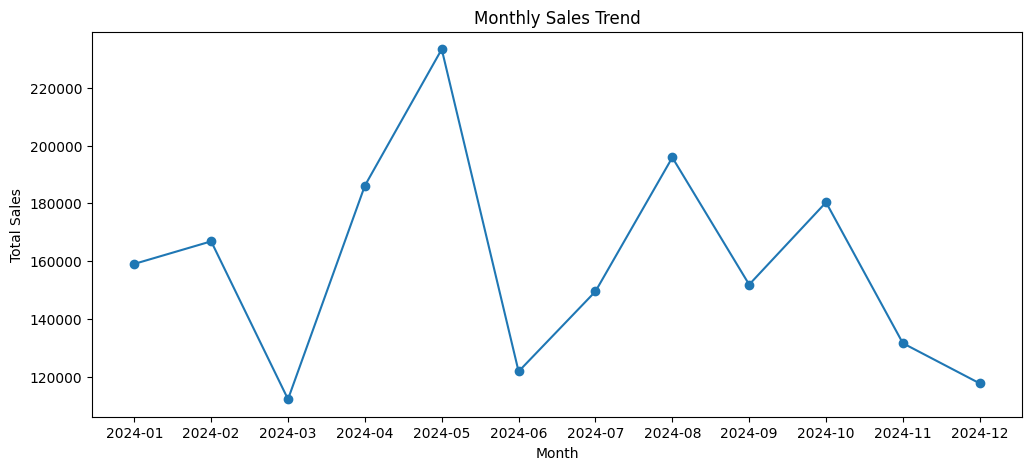

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [88]:
customer_revenue = (
    df.groupby("customer_id")["total_sales"]
      .sum()
      .sort_values(ascending=False)
)

In [89]:
customer_revenue.head(10)

customer_id
1146    40300
1110    34855
1136    27800
1027    26950
1098    26775
1143    26525
1003    26350
1108    26255
1076    26100
1186    25575
Name: total_sales, dtype: int64

In [90]:
customer_orders = (
    df.groupby("customer_id")["order_id"]
      .nunique()
      .sort_values(ascending=False)
)

In [91]:
customer_orders.head(10)

customer_id
1110    12
1172    11
1086    11
1170    11
1187    10
1076    10
1003     9
1041     9
1117     9
1133     9
Name: order_id, dtype: int64

In [96]:
customer_units = (
    df.groupby("customer_id")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

In [97]:
customer_units.head(10)

customer_id
1110    61
1021    59
1143    56
1044    55
1041    53
1170    53
1172    51
1150    50
1086    50
1163    50
Name: quantity, dtype: int64

In [98]:
customer_aov = (
    df.groupby("customer_id")["total_sales"]
      .mean()
      .sort_values(ascending=False)
)
customer_aov.head(10)

customer_id
1138    10800.000000
1093     6600.000000
1146     5757.142857
1096     5175.000000
1032     4957.500000
1177     4950.000000
1132     4800.000000
1136     4633.333333
1159     4550.000000
1189     4540.000000
Name: total_sales, dtype: float64

In [99]:
customer_summary = (
    df.groupby("customer_id")
      .agg(
          total_revenue=("total_sales", "sum"),
          total_orders=("order_id", "nunique"),
          total_units=("quantity", "sum"),
          average_order_value=("total_sales", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

In [100]:
customer_summary.head(10)

,total_revenue,total_orders,total_units,average_order_value
customer_id,,,,
1146,40300,7,46,5757.142857
1110,34855,12,61,2904.583333
1136,27800,6,29,4633.333333
1027,26950,7,37,3850.000000
1098,26775,8,45,3346.875000
1143,26525,8,56,3315.625000
1003,26350,9,41,2927.777778
1108,26255,7,46,3750.714286
1076,26100,10,49,2610.000000


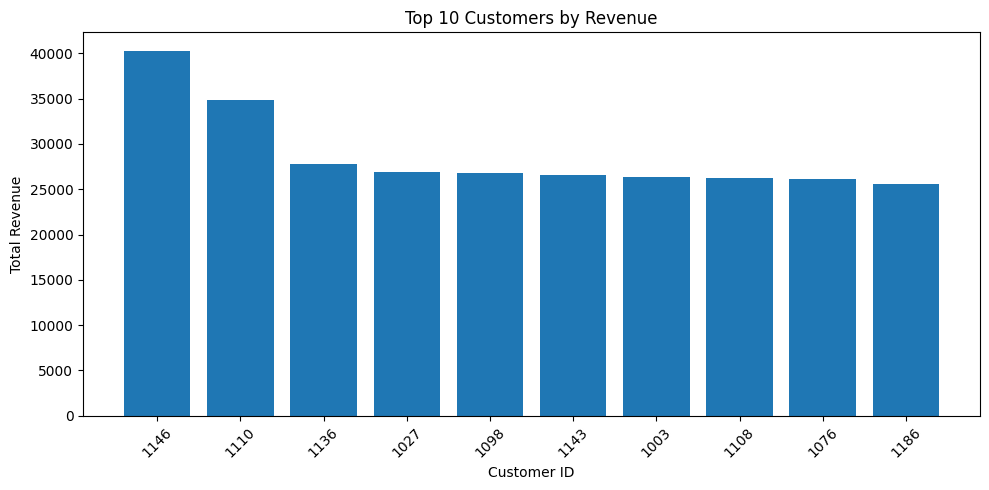

In [101]:
top_customers = customer_summary.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_customers.index.astype(str),
    top_customers["total_revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [102]:
product_summary = (
    df.groupby("product")
      .agg(
          total_revenue=("total_sales", "sum"),
          total_units=("quantity", "sum"),
          total_orders=("order_id", "nunique"),
          average_order_value=("total_sales", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

In [103]:
product_summary

,total_revenue,total_units,total_orders,average_order_value
product,,,,
Laptop,408795,989,190,2151.552632
Phone,349460,892,184,1899.239130
Tablet,341315,848,166,2056.114458
Headphones,287805,728,162,1776.574074
Monitor,163060,524,105,1552.952381
Keyboard,151350,427,83,1823.493976
Mouse,106590,314,59,1806.610169
Unknown,97760,252,51,1916.862745


In [106]:
product_region_sales = (
    df.groupby(["product", "region"])["total_sales"]
      .sum()
      .unstack()
      
)

product_region_sales

region,East,North,South,West
product,,,,
Headphones,78295,97130,56220,56160
Keyboard,20910,71430,27750,31260
Laptop,80840,175865,71110,80980
Monitor,64125,49055,17045,32835
Mouse,8085,37095,30225,31185
Phone,73980,134590,39450,101440
Tablet,60140,131025,68955,81195
Unknown,17575,58490,13510,8185


In [107]:
best_product_by_region = (
    df.groupby(["region", "product"])["total_sales"]
      .sum()
      .reset_index()
)

In [108]:
best_product_by_region = (
    best_product_by_region
    .loc[
        best_product_by_region.groupby("region")["total_sales"].idxmax()
    ]
    .sort_values("region")
)

In [109]:
best_product_by_region

,region,product,total_sales
2,East,Laptop,80840
10,North,Laptop,175865
18,South,Laptop,71110
29,West,Phone,101440


In [111]:
product_region_pct = (
    df.groupby(["region", "product"])["total_sales"]
      .sum()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
)

In [112]:
product_region_pct

region  product   
East    Headphones    19.382349
        Keyboard       5.176383
        Laptop        20.012378
        Monitor       15.874489
        Mouse          2.001485
        Phone         18.314148
        Tablet        14.887981
        Unknown        4.350786
North   Headphones    12.870356
        Keyboard       9.464939
        Laptop        23.303254
        Monitor        6.500106
        Mouse          4.915328
        Phone         17.834049
        Tablet        17.361663
        Unknown        7.750305
South   Headphones    17.337671
        Keyboard       8.557815
        Laptop        21.929595
        Monitor        5.256503
        Mouse          9.321080
        Phone         12.165975
        Tablet        21.265015
        Unknown        4.166345
West    Headphones    13.269067
        Keyboard       7.385880
        Laptop        19.133352
        Monitor        7.758010
        Mouse          7.368160
        Phone         23.967489
        Tablet       

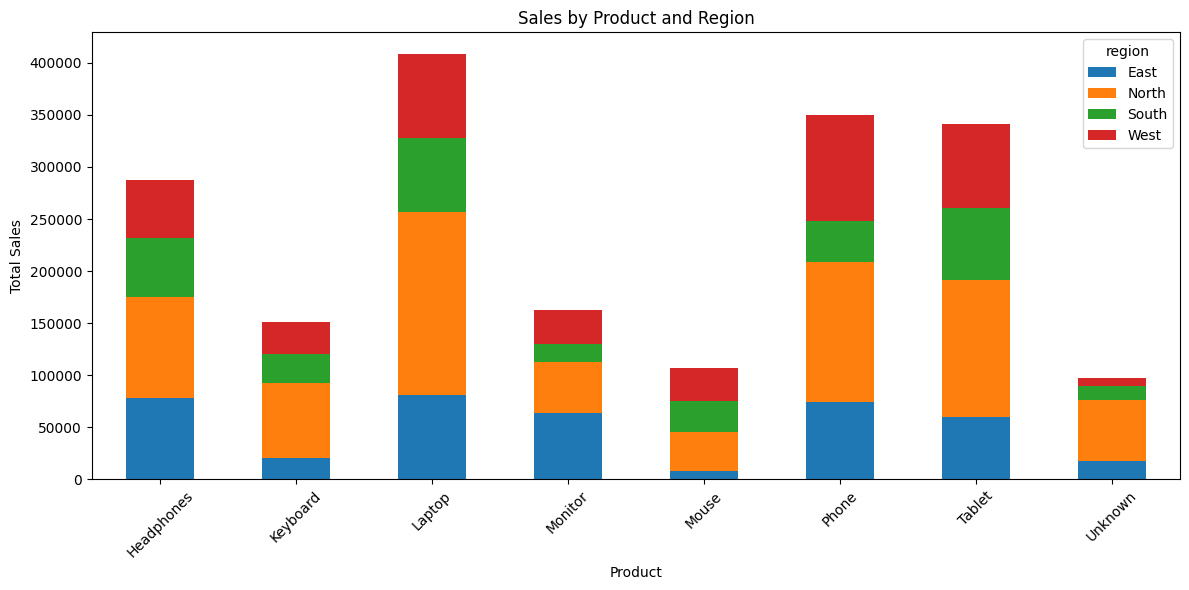

In [113]:
product_region_sales.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Sales by Product and Region")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [114]:
kpis = {
    "Total Revenue": df["total_sales"].sum(),
    "Total Orders": df["order_id"].nunique(),
    "Total Units Sold": df["quantity"].sum(),
    "Average Order Value": df["total_sales"].mean(),
    "Number of Customers": df["customer_id"].nunique(),
    "Number of Products": df["product"].nunique(),
    "Number of Regions": df["region"].nunique()
}

kpis

{'Total Revenue': np.int64(1906135),
 'Total Orders': 1000,
 'Total Units Sold': np.int64(4974),
 'Average Order Value': np.float64(1906.135),
 'Number of Customers': 200,
 'Number of Products': 8,
 'Number of Regions': 4}

In [115]:
product_summary = (
    df.groupby("product")
      .agg(
          total_revenue=("total_sales", "sum"),
          total_units=("quantity", "sum"),
          total_orders=("order_id", "nunique"),
          average_order_value=("total_sales", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

In [116]:
best_product = product_summary["total_revenue"].idxmax()
best_product_revenue = product_summary["total_revenue"].max()

worst_product = product_summary["total_revenue"].idxmin()
worst_product_revenue = product_summary["total_revenue"].min()

In [117]:
print("Best product:", best_product)
print("Revenue:", best_product_revenue)

print("Lowest revenue product:", worst_product)
print("Revenue:", worst_product_revenue)

Best product: Laptop
Revenue: 408795
Lowest revenue product: Unknown
Revenue: 97760


In [118]:
best_by_units = product_summary["total_units"].idxmax()

print("Best product by revenue:", best_product)
print("Best product by units:", best_by_units)

Best product by revenue: Laptop
Best product by units: Laptop


In [119]:
region_summary = (
    df.groupby("region")
      .agg(
          total_revenue=("total_sales", "sum"),
          total_orders=("order_id", "nunique"),
          total_units=("quantity", "sum"),
          average_order_value=("total_sales", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

region_summary

,total_revenue,total_orders,total_units,average_order_value
region,,,,
North,754680,408,2003,1849.705882
West,423240,221,1097,1915.113122
East,403950,197,1006,2050.507614
South,324265,174,868,1863.591954


In [122]:
best_region = region_summary["total_revenue"].idxmax()
best_region_revenue = region_summary["total_revenue"].max()

print("Best region:", best_region)
print("Revenue:", best_region_revenue)

Best region: North
Revenue: 754680


In [123]:
customer_summary = (
    df.groupby("customer_id")
      .agg(
          total_revenue=("total_sales", "sum"),
          total_orders=("order_id", "nunique"),
          total_units=("quantity", "sum"),
          average_order_value=("total_sales", "mean")
      )
)

In [124]:
customer_summary["segment"] = pd.qcut(
    customer_summary["total_revenue"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [125]:
customer_summary["segment"].value_counts()

segment
Low Value       67
High Value      67
Medium Value    66
Name: count, dtype: int64

In [126]:
segment_revenue = (
    customer_summary.groupby("segment", observed=True)["total_revenue"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

segment
High Value      1166395
Medium Value     544930
Low Value        194810
Name: total_revenue, dtype: int64

In [127]:
segment_percentage = (
    segment_revenue / segment_revenue.sum() * 100
)

segment_percentage

segment
High Value      61.191626
Medium Value    28.588216
Low Value       10.220158
Name: total_revenue, dtype: float64

In [128]:
correlation = df[
    ["quantity", "unit_price", "total_sales"]
].corr()

correlation

,quantity,unit_price,total_sales
quantity,1.000000,-0.017219,0.422272
unit_price,-0.017219,1.000000,0.781350
total_sales,0.422272,0.781350,1.000000


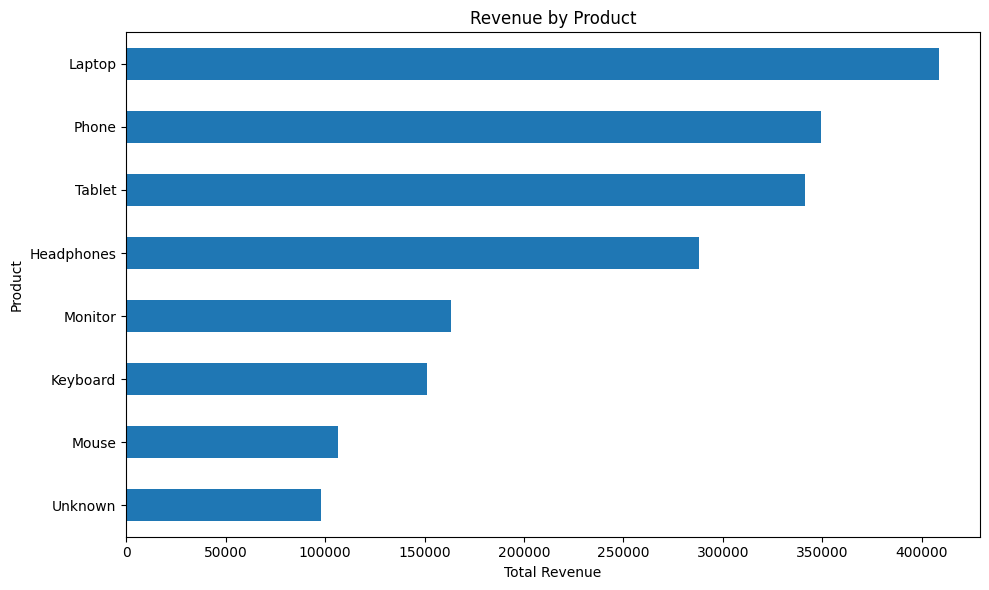

In [129]:
product_summary["total_revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Revenue by Product")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

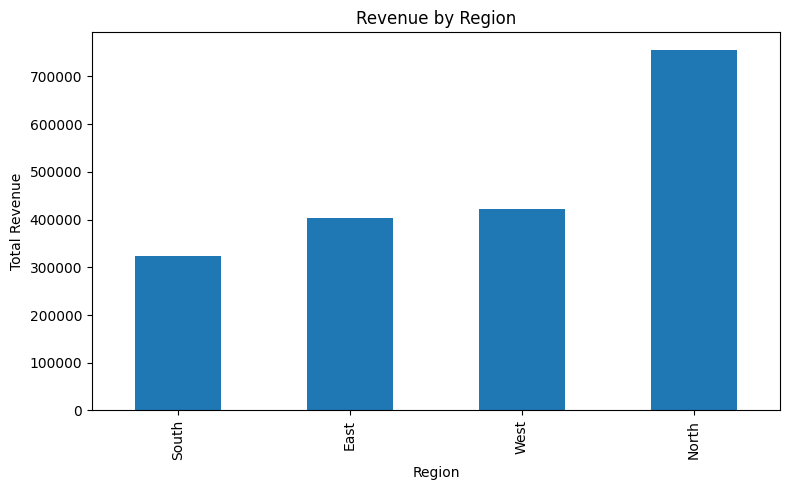

In [130]:
region_summary["total_revenue"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

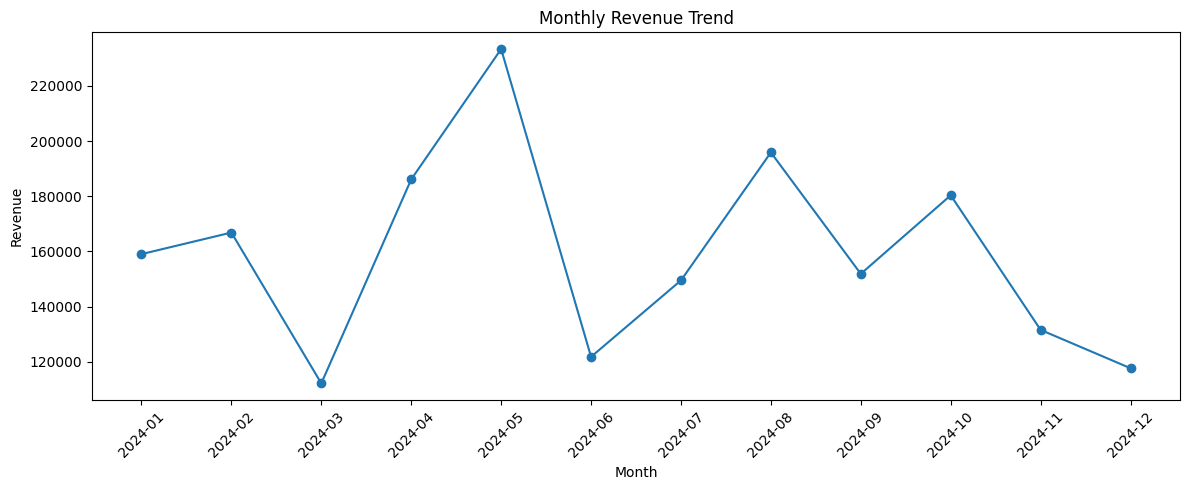

In [131]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

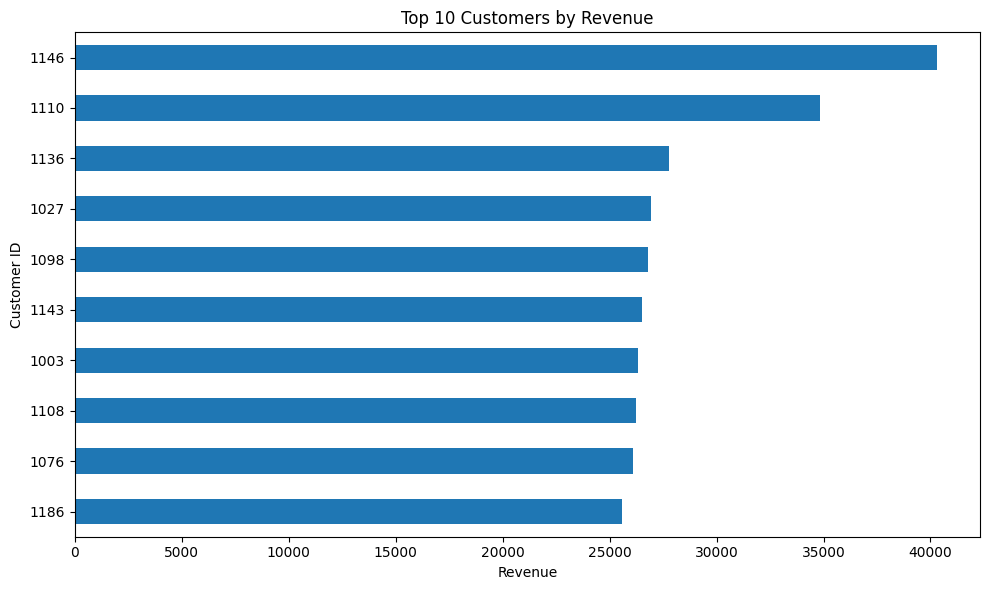

In [132]:
customer_summary.sort_values(
    "total_revenue",
    ascending=False
).head(10)["total_revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

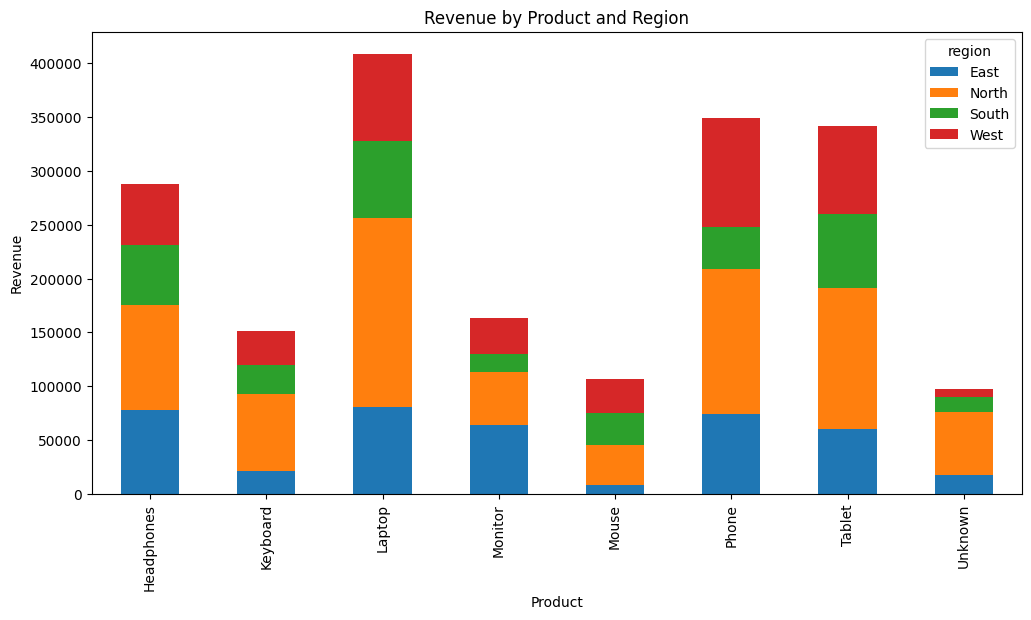

In [134]:
product_region_sales = (
    df.groupby(["product", "region"])["total_sales"]
      .sum()
      .unstack(fill_value=0)
)

product_region_sales.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Revenue by Product and Region")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [135]:
dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Units Sold",
        "Average Order Value",
        "Number of Customers"
    ],
    "Value": [
        df["total_sales"].sum(),
        df["order_id"].nunique(),
        df["quantity"].sum(),
        df["total_sales"].mean(),
        df["customer_id"].nunique()
    ]
})

dashboard_kpis

,KPI,Value
0,Total Revenue,1906135.000
1,Total Orders,1000.000
2,Total Units Sold,4974.000
3,Average Order Value,1906.135
4,Number of Customers,200.000


In [138]:
product_summary

,total_revenue,total_units,total_orders,average_order_value
product,,,,
Laptop,408795,989,190,2151.552632
Phone,349460,892,184,1899.239130
Tablet,341315,848,166,2056.114458
Headphones,287805,728,162,1776.574074
Monitor,163060,524,105,1552.952381
Keyboard,151350,427,83,1823.493976
Mouse,106590,314,59,1806.610169
Unknown,97760,252,51,1916.862745


In [139]:
monthly_sales

month
2024-01    159030
2024-02    166845
2024-03    112165
2024-04    186125
2024-05    233380
2024-06    121780
2024-07    149500
2024-08    195890
2024-09    151870
2024-10    180355
2024-11    131550
2024-12    117645
Freq: M, Name: total_sales, dtype: int64

In [140]:
region_summary

,total_revenue,total_orders,total_units,average_order_value
region,,,,
North,754680,408,2003,1849.705882
West,423240,221,1097,1915.113122
East,403950,197,1006,2050.507614
South,324265,174,868,1863.591954


In [141]:
customer_summary.head(10)

,total_revenue,total_orders,total_units,average_order_value,segment
customer_id,,,,,
1000,9395,5,18,1879.000000,Medium Value
1001,1375,2,11,687.500000,Low Value
1002,4800,2,11,2400.000000,Low Value
1003,26350,9,41,2927.777778,High Value
1004,1050,3,17,350.000000,Low Value
1005,8650,3,17,2883.333333,Medium Value
1006,6900,4,25,1725.000000,Medium Value
1007,3740,5,26,748.000000,Low Value
1008,6685,5,24,1337.000000,Medium Value


In [142]:
top10_revenue = (
    customer_summary
    .sort_values("total_revenue", ascending=False)
    .head(10)["total_revenue"]
    .sum()
)

top10_percentage = (
    top10_revenue / df["total_sales"].sum()
) * 100

print("Top 10 revenue:", top10_revenue)
print("Top 10 revenue share:", top10_percentage)

Top 10 revenue: 287485
Top 10 revenue share: 15.082090198228352


In [143]:
best_product_by_region = (
    df.groupby(["region", "product"])["total_sales"]
      .sum()
      .reset_index()
)

best_product_by_region = (
    best_product_by_region.loc[
        best_product_by_region.groupby("region")["total_sales"].idxmax()
    ]
    .sort_values("region")
)

best_product_by_region

,region,product,total_sales
2,East,Laptop,80840
10,North,Laptop,175865
18,South,Laptop,71110
29,West,Phone,101440


In [144]:
import matplotlib.pyplot as plt
import pandas as pd

# KPIs
total_revenue = df["total_sales"].sum()
total_orders = df["order_id"].nunique()
total_units = df["quantity"].sum()
average_order_value = df["total_sales"].mean()
total_customers = df["customer_id"].nunique()

# Product
product_sales = (
    df.groupby("product")["total_sales"]
      .sum()
      .sort_values(ascending=True)
)

# Region
region_sales = (
    df.groupby("region")["total_sales"]
      .sum()
      .sort_values(ascending=True)
)

# Monthly
monthly_sales = (
    df.groupby("month")["total_sales"]
      .sum()
)

# Top customers
top_customers = (
    df.groupby("customer_id")["total_sales"]
      .sum()
      .sort_values(ascending=True)
      .tail(10)
)

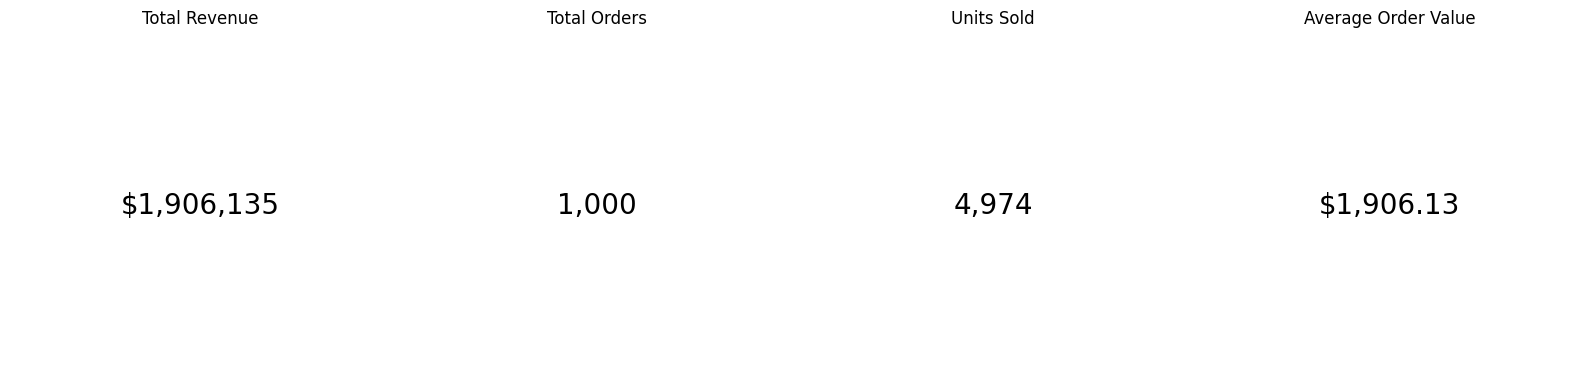

In [145]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].text(0.5, 0.5, f"${total_revenue:,.0f}",
             ha="center", va="center", fontsize=20)
axes[0].set_title("Total Revenue")
axes[0].axis("off")

axes[1].text(0.5, 0.5, f"{total_orders:,}",
             ha="center", va="center", fontsize=20)
axes[1].set_title("Total Orders")
axes[1].axis("off")

axes[2].text(0.5, 0.5, f"{total_units:,}",
             ha="center", va="center", fontsize=20)
axes[2].set_title("Units Sold")
axes[2].axis("off")

axes[3].text(0.5, 0.5, f"${average_order_value:,.2f}",
             ha="center", va="center", fontsize=20)
axes[3].set_title("Average Order Value")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# Business Insights****

🏆 Product


Laptop is the highest-revenue product, generating approximately 408,795 in revenue. Phone ****and Tablet follow as the next strongest products.

🌍 Region

North#  is the strongest region, generating approximately 754,680 in revenue and accounting for around 40% of total revenue

📅 Time

mai#  recorded the highest monthly revenue, while mars#  recorded the lowest. This indicates noticeable fluctuations in demand throughout 2024


# Business Recommendations


1. Focus on high-performing products

The company should maintain strong inventory availability and marketing efforts for Laptop, Phone, and Tablet because these products generate the largest share of revenue.

2. Strengthen weaker regions

North is performing exceptionally well, but the lower-performing regions represent potential growth opportunities. The company should investigate differences in customer demand, marketing reach, and product preferences.

3. Improve data quality

The presence of Unknown products indicates incomplete product information. Improving data collection at the point of sale would make future product analysis more reliable.

4. Monitor monthly fluctuations

Because monthly revenue varies significantly, the company should investigate the reasons behind peaks and declines and use these patterns for inventory and marketing planning


# Conclusion

This project analyzed sales data for 2024 with the objective of identifying
sales patterns, product performance, regional performance, customer behavior,
and monthly trends.

The analysis began with data quality assessment and cleaning, including
handling missing values, duplicate orders, inconsistent region names, and
inconsistent sales calculations.

After cleaning, the dataset contained 1,000 unique orders and generated
1,906,135 in total revenue from 4,974 units sold.

The exploratory analysis showed that Laptop was the strongest product by
revenue, while North was the strongest region. The monthly analysis also
revealed fluctuations in sales throughout the year, while customer analysis
identified the most valuable customers based on revenue contribution.

Overall, the analysis demonstrates how data cleaning, exploratory analysis,
and visualization can transform raw sales data into actionable business
insights. The findings can support decisions related to inventory management,
regional marketing, product strategy, and customer retention.